## Finding observations of Mars in the ESO archive

S. Erard, April 2026, adapted from Baptiste Cecconi, Nov 2025 on Jupiter (https://github.com/epn-vespa/tutorials/blob/master/misc/searching_archives/stmoc-jupiter.ipynb) and variation for Mars at HST


The Jupiter example is generalized to extract data products related to a longer period, typically over a complete Martian year (centered on the close opposition of 2003). This exaple focuses on the ESO archive at CADC.
This requires to optimize the request to the archive and the MOC computation time.

Changes wrt the initial Jupiter example :
- the TAP request is filtered in ecliptic longitude (restained to a narrow ecliptic band)
- the MOC computation uses another, faster method (from_cones) adapted to long periods (i.e. significant part of the orbit)
- assement is provided through comparison with the ESO TAP service.


In [1]:
import requests
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
import numpy
from mocpy import MOC, STMOC, TimeMOC

from pathlib import Path
DATADIR = Path('.') / "data" 
DATADIR.mkdir(exist_ok=True)

# LTE ephemeris webservices

The LTE lab (https://lte.observatoiredeparis.psl.eu) is proposing a Solar System Ephemeris (https://ssp.imcce.fr/webservices/). 

We will use here the Miriade `ephemcc` webservice (for positional ephemerides)

Review the API configuration at https://ssp.imcce.fr/webservices/miriade/api/ephemcc/

Fill in the following query parameters for: 
- Target: Mars
- Observer: 309 (VLT / Paranal. Assumed to handle also La SIlla site)
- Start time: 1st Jul 2002
- Stop time: 30 Sept 2004 (~ 1 Martian year centered around 2003 opposition)
- 10 min step for ~ 2 years (720 days)
- select the "votable" output format

NB: each field has specific syntax, as described in the API specification (see link above) 

In [2]:
dt = 10 * u.minute  # sampling time, minutes

ephemcc_url = "https://ssp.imcce.fr/webservices/miriade/api/ephemcc.php?"
ephemcc_params = {
    "-name": "p:Mars",
    "-observer": "309",
    "-ep": "2002-07-01T00:00:00",
    "-nbd": f"{720*24*6}",
    "-step": f"{int(dt.value)}m",
    "-from": "VESPA-test",
    "-mime": "votable",
}

In [3]:
query = ephemcc_url+"&".join([f"{k}={v}" for k,v in ephemcc_params.items()])
print(query)

https://ssp.imcce.fr/webservices/miriade/api/ephemcc.php?-name=p:Mars&-observer=309&-ep=2002-07-01T00:00:00&-nbd=103680&-step=10m&-from=VESPA-test&-mime=votable


**In order to avoid overloading the LTE servers, update the `recompute` flag once you are happy with your dataset**

In [4]:
output_file = DATADIR / "mars-ephemcc_VLT.xml"
recompute = False
#recompute = True

if recompute:
    resp = requests.get(query)
    with open(output_file, 'w') as f:
        f.write(resp.content.decode())

The data is available in a VOTable file. 

The `Table` object of astropy can read such file, with the format option "votable". 

more info: https://docs.astropy.org/en/stable/table/index.html 

In [5]:
data = Table.read(output_file, format="votable")

Using the astropy `Time` object construct 2 variables containing the start and end times of each interval of the ephemcc query result.  

More info: https://docs.astropy.org/en/stable/time/index.html

The start times (named `times_start`) are the ephemeris times, and the end times (named `times_and`) are the same, with 1 time step added. So that we get a full list of intervals filling the overall studied time period.   

In [6]:
times_start = Time([d for d in data["date"].data], format='isot')
times_end = times_start + TimeDelta(dt.to(u.s), format="sec")

Using the astropy `SkyCoord` object construct the series of positions for each ephemeris computation. 

More info: https://docs.astropy.org/en/stable/coordinates/index.html

Name your position variable `positions`. Also extract the distance of the target (variable `distances`) 

In [7]:
positions = SkyCoord(data["RA"], data["DEC"], unit=(u.hourangle, u.deg))
distances = data['dobs']

Check the units of the `distances` variable and convert to `km` 

In [8]:
distances.to('km').value

array([3.90252394e+08, 3.90255492e+08, 3.90258588e+08, ...,
       3.70041654e+08, 3.70046921e+08, 3.70052190e+08], shape=(103680,))

Compute the size of Mars (check the values in *arcsec*), using the Mars radius = 3390 km 

In [9]:
sizes = numpy.atan2(3390, distances.to(u.km).value) * u.rad * 2
sizes.to(u.arcsec)

<Quantity [3.5835152 , 3.58348675, 3.58345832, ..., 3.77923775, 3.77918396,
           3.77913014] arcsec>

**The sampled trajectory is easily plotted in TOPCAT**

- The trajectory traces a large loop around the opposition, which corresponds to Mars retrograde motion as the Earth overtakes it from the inside
- Small variations with a quasi-period of 24h are observed especially near opposition with amplitude ~ 25". This is the daily parallax observed from the ground.


**Define which MOC order should be used to have a MOC resolution consistent with the data.**

(NB: a too low order will over estimate the footprints, a too high order will take a long time to compute. This must be optimised together with time sampling step).

In [10]:
moc_order = 12
# 13 corresponds to 26" on the sky, ~ disk size at opposition that year (no need to fit very distant configurations, they are close to the Sun)
# Order 12 may be better suited to grab all data files

Now we compute the STMOC objects (and additional merged TMOC and MOC objects) 

Documentation on MOC: 
- IVOA Specification: https://www.ivoa.net/documents/MOC/
- MocPy library: https://cds-astro.github.io/mocpy/index.html

In [11]:
%%time
#spatial_coverages = [
#    MOC.from_cone(pos.ra, pos.dec, radius=siz.to(u.deg)/2, max_depth=moc_order)
#    for pos, siz in zip(positions, sizes)
#]

#stmoc_ephemcc = STMOC.from_spatial_coverages(
#    times_start,
#    times_end,
#    spatial_coverages,
#)

# other method, faster (beware of changing list format)
dec = positions.dec
ra = positions.ra
spatial_coverages = [
    MOC.from_cones(ra, dec, radius=sizes.to(u.deg)/2, max_depth=moc_order)
]

stmoc_ephemcc = STMOC.from_spatial_coverages(
    times_start,
    times_end,
    spatial_coverages[0],
)

tmoc_ephemcc = TimeMOC.from_time_ranges(
    times_start[0],
    times_end[-1]
)

moc_ephemcc = stmoc_ephemcc.query_by_time(tmoc_ephemcc)

CPU times: user 821 ms, sys: 145 ms, total: 966 ms
Wall time: 699 ms


We can display the STMOC ranges: 

In [12]:
print("STMOC min time:", Time(tmoc_ephemcc.min_time.mjd[0], format='mjd').isot)
print("STMOC max time:", Time(tmoc_ephemcc.max_time.mjd[-1], format='mjd').isot)
print("Declination min /max:", min(positions.dec), max(positions.dec))

# convert to ecliptic coord
coord_ecl=positions.transform_to('geocentricmeanecliptic')
print("Eclip lat min /max:", min(coord_ecl.lat), max(coord_ecl.lat))


STMOC min time: 2002-07-01T00:00:12.931
STMOC max time: 2004-06-20T00:05:19.246
Declination min /max: -23d34m18.5441s 24d40m31.8937s
Eclip lat min /max: -6d42m16.90856214s 1d14m52.20221477s


# Query a TAP service for ESO data

1) use the `https://archive.eso.org/tap_obs` TAP server and query the `dbo.raw` table, with a time interval selection on parameter `mjd_obs`(in Modified Julian Date).

2) The strategy is to narrow the TAP request as much as possible to speed up the MOC computation later.

In addition, we therefore:
- request the period of interest
- request the range of interest in spatial coordinates (this is very efficient to restrain the result size and speed up later operations, as the planets have limited excursion)
- use ecliptic latitude as spatial filter, rather than declination (much narrower excursion for planets)
- filter on processing level (and possibly other restrictions on product types)

In the query, you can retrieve the following parameters: 
- `access_url`: URL to access the data
- `dp_cat`: calibration level
- `dp_tech`: data product type (i.e.: image, spectrum...)
- `lambda_min`: lower bound of the spectral range (wavelength in nm)
- `lambda_max`: upper bound of the spectral range (wavelength in nm)
- `telescope`: name of the observing facility
- `instrument`: name of the instrument
- `dp_id`: identifier of the data product
- `dec`: spatial coordinate (Declination)
- `ra`: spatial coordinate (Right Ascension)
- `s_region`: spatial region observed (in STCS format)
- `mjd_obs`: start of acquisition in MJD
- `target`: name of the main target, as defined by the observer (sometimes empty)
- `object`: name of specific target at time of observation, as defined by the observer (often empty)
- `prog_title`: name of programme, may indicate target name
- `pi_coi`: name of programme PI & CoIs




In [13]:
from pyvo.dal import TAPService

In [14]:
tap_service = TAPService("https://archive.eso.org/tap_obs")


In [15]:
query = f"""
SELECT   access_url, exposure, prog_title, dp_tech,
            lambda_min, lambda_max, instrument, telescope,
            dp_id, dec, ra, s_region, mjd_obs, date_obs, target, object,
             DEGREES( ASIN(
      SIN(RADIANS(dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(ra)))  ) AS lat_ecliptique
     FROM dbo.raw
     WHERE  mjd_obs between 52456.00369498074 and 53176.00369498074
     and s_region IS NOT NULL
	 and dp_cat = 'SCIENCE'
     and   DEGREES(
    ASIN(
      SIN(RADIANS(dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(ra))
    )
  ) BETWEEN -7 AND 2

"""

print(query)


SELECT   access_url, exposure, prog_title, dp_tech,
            lambda_min, lambda_max, instrument, telescope,
            dp_id, dec, ra, s_region, mjd_obs, date_obs, target, object,
             DEGREES( ASIN(
      SIN(RADIANS(dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(ra)))  ) AS lat_ecliptique
     FROM dbo.raw
     WHERE  mjd_obs between 52456.00369498074 and 53176.00369498074
     and s_region IS NOT NULL
	 and dp_cat = 'SCIENCE'
     and   DEGREES(
    ASIN(
      SIN(RADIANS(dec)) * COS(RADIANS(23.43928))
      - COS(RADIANS(dec)) * SIN(RADIANS(23.43928)) * SIN(RADIANS(ra))
    )
  ) BETWEEN -7 AND 2




In [16]:
%%time
obscore_file = DATADIR / "ESO_TAP_Mars_VLT.xml"
recompute = False
#recompute = True

# need to foresee overflows on ESO server
if recompute:
    result = tap_service.search(query, maxrec=100000)
    with open(obscore_file, 'w') as f:
        result.votable.to_xml(f)

CPU times: user 5.15 s, sys: 186 ms, total: 5.34 s
Wall time: 10.8 s


In [17]:
obscore = Table.read(obscore_file, format="votable")

For computing the STMOC, we cannot use the `MOC.from_stcs()` method, because the `s_region` in this table only provides positions (not areas). Instead, we use the same `from_cones` method as above.

*Hint*: STMOC are readily displayed in Aladin, using the menu item View > Create a time view

In [18]:
%%time

# won't work, the original s_region format is not supported
#spatial_coverages = [
#    MOC.from_stcs(s_region, max_depth=moc_order)
#    for s_region in obscore['s_region'] 
#]

sizes = 20 * u.arcsec 
spatial_coverages = [
    MOC.from_cones(obscore['ra'], obscore['dec'], radius=sizes, max_depth=moc_order)
]


stmoc_observation = STMOC.from_spatial_coverages(
    Time(obscore['mjd_obs'], format='mjd'),
    Time(obscore['mjd_obs']+ obscore['exposure'], format='mjd'),
    spatial_coverages[0]
)

tmoc_observation = TimeMOC.from_time_ranges(
    Time(min(obscore['mjd_obs']), format='mjd'),
    Time(max(obscore['mjd_obs']+ obscore['exposure']), format='mjd')
)

moc_observation = stmoc_observation.query_by_time(tmoc_observation)

CPU times: user 9min 14s, sys: 3min 12s, total: 12min 27s
Wall time: 1min 24s


In [19]:
# Helper function for displaying the MOCs

from astropy.visualization.wcsaxes.frame import EllipticalFrame

def plot(moc, title=""):
    """Create a plot of a MOC."""
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(15, 10))

    from astropy.wcs import WCS

    wcs = WCS(naxis=2)
    wcs.wcs.ctype = ["RA---AIT", "DEC--AIT"]
    wcs.wcs.crval = [110.0, 0.0]
    wcs.wcs.cdelt = [-0.675, 0.675]
    wcs.wcs.crpix = [240.5, 120.5]

    ax = fig.add_subplot(1, 1, 1, projection=wcs, frame_class=EllipticalFrame)

    moc.fill(
        ax=ax,
        wcs=wcs,
        edgecolor="r",
        facecolor="r",
        linewidth=1.0,
        fill=True,
        alpha=0.5,
    )
    moc.border(ax=ax, wcs=wcs, color="black", alpha=0.5)

    ax.set_aspect(1.0)

    plt.xlabel("ra")
    plt.ylabel("dec")
    if title:
        plt.title(title)
    plt.grid(color="black", linestyle="dotted")
    plt.show()
    plt.close()


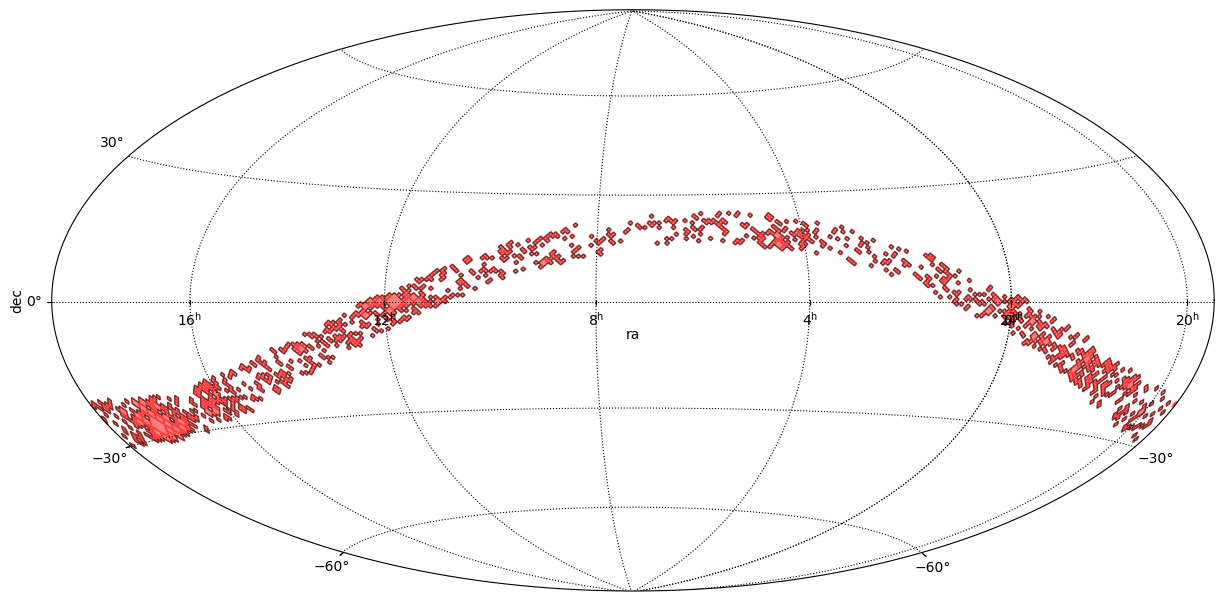

In [20]:
plot(moc_observation)

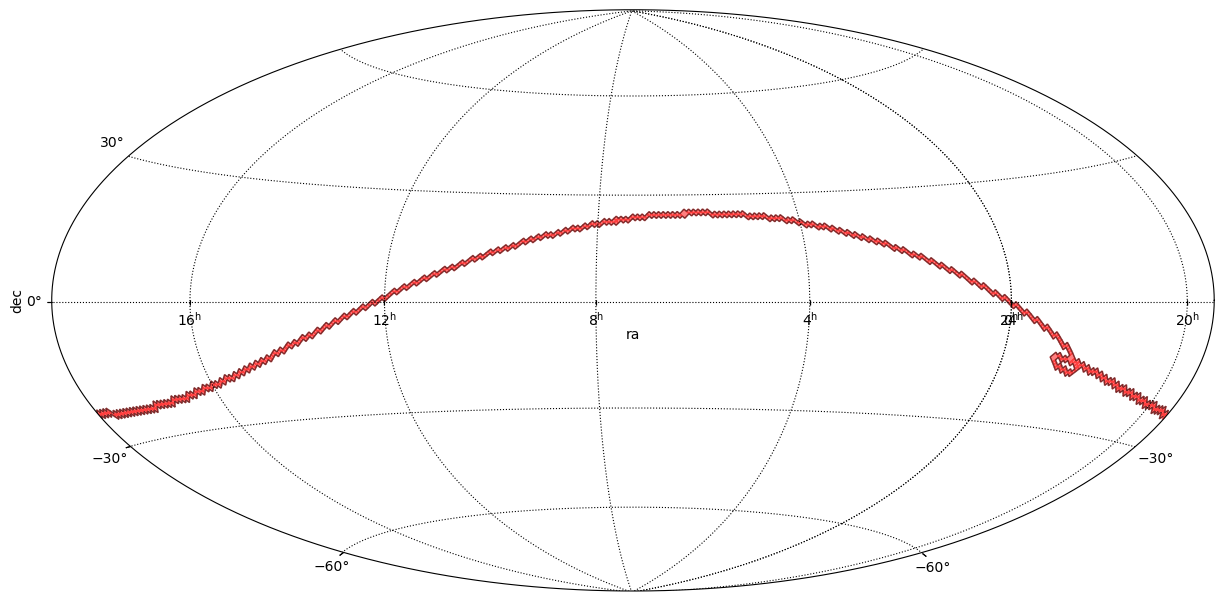

In [21]:
plot(moc_ephemcc)

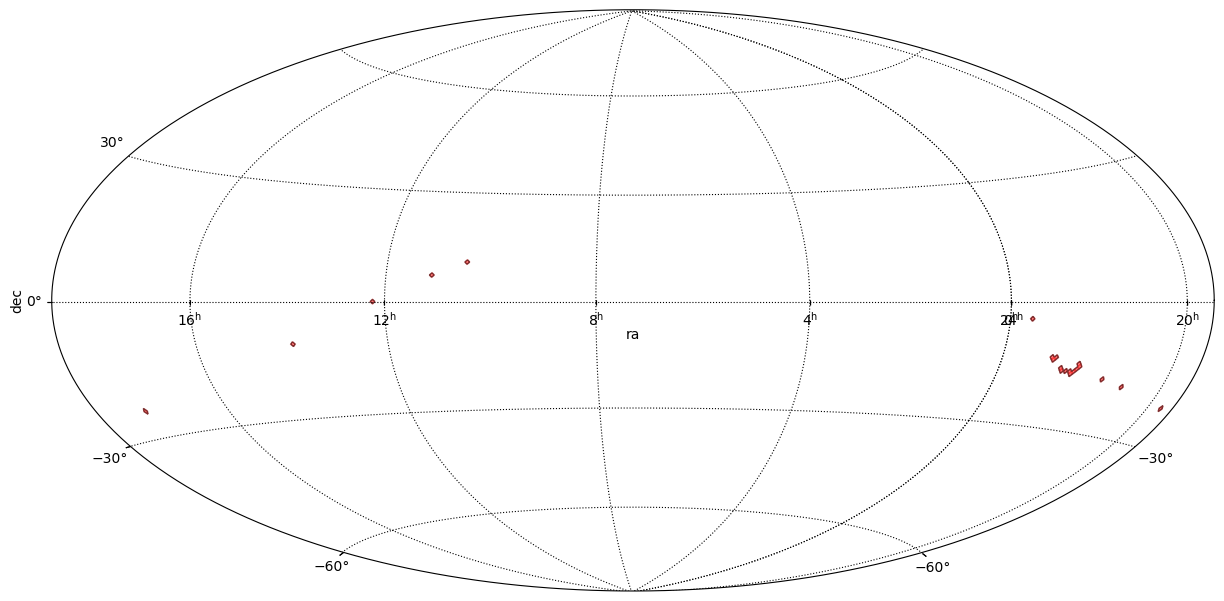

In [22]:
plot(moc_observation.intersection(moc_ephemcc))

Since the TAP query includes all observations of the time interval, we want to remove observations not targeting Mars.

Build a mask array (`True` = Mars is in field of view). Use the `.intersection()` method iteratively. This step is rather slow.

In [23]:
%%time
mask = []
for row, cov in zip(obscore, spatial_coverages[0]):
    stmoc_row = STMOC.from_spatial_coverages(
        Time(row['mjd_obs'], format='mjd'),
        Time(row['mjd_obs']+row['exposure'], format='mjd'),
        cov
    )
    if stmoc_row.intersection(stmoc_ephemcc).is_empty():
        mask.append(False)
    else:
        print(row['dp_id'], row['dp_tech'], row['instrument'], row['target'])
        mask.append(True)

EFOSC.2003-12-01T03:09:18.804 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T02:52:37.333 IMAGE EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T02:54:07.809 IMAGE EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T02:55:51.968 IMAGE EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T02:57:21.911 IMAGE EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T02:56:36.773 IMAGE EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:11:23.395 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:07:56.447 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:09:58.944 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:22:06.745 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:24:08.626 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:12:43.838 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EFOSC.2003-12-01T03:23:28.061 SPECTRUM EFOSC/3.2 MARS_03UT_NIGHT2
EMMI.2003-10-01T02:49:52.525 IMAGE EMMI/2.3 MARS
EMMI.2003-10-01T02:54:40.838 IMAGE EMMI/2.3 MARS
EMMI.2003-10-01T02:38:35.901 IMAGE EMMI/2.3 MARS
EMMI.2003-

List the unique values of `pd_id` (dataproduct ID), `target` used by the observer, plus instrument and mode

Using order 12, we find 586 science results from ESO. Only 11 of them are not tagged as Mars: 6 Michele-Star (which seems to be Mars), 2 Phobos, and 3 NACO observations with no target name.

**Point of comparison:**

SELECT * FROM dbo.raw where(target LIKE '%mars%') and dp_cat = 'SCIENCE'

yields 2748 results, 600 of which in the period of interest. 10 of them are obvious false alarms (target name includes "MARSEILLE"), leaving 590 relevant results... No NACO result is included.

Results not found with ST-MOC include the 10 false alarms from the catalogue + 15 products related to Mars around opposition. Some of those are clearly off-pointings, but not all. Extra results are the 11 products mentioned above.

**Analysis**:

- The ST_MOC method finds only a few untagged observations - including Phobos ones in this case. This is demonstrating the quality of ESO catalogue.
- It apparently misses some regular observations. This can result from a too narrow FoV or from an ephemeris mismatch (missing observations are from the NTT in La Silla, not the VLT).
- At any rate, ephemeris MOC order appears critical (same as HST assessement)

**Conclusion**:

This method is a good way to grab (almost) all observations related to planets in the ESO archive - mostly off-pointing measurements may be lost in the process.
